# Train, val, test split

In [2]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import random
import json
import shutil
from collections import Counter
import optuna

2026-04-23 00:00:33.768125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776902433.971521   15557 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776902434.032131   15557 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776902434.470712   15557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776902434.470755   15557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776902434.470758   15557 computation_placer.cc:177] computation placer alr

In [3]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
DATA_DIR = '/kaggle/input/datasets/piccini/wikiart-clean/wikiart_clean'

In [5]:
ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical",
    shuffle=True,
    seed=42,
    validation_split=0.3,
    subset="both",
)


Found 13172 files belonging to 23 classes.
Using 9221 files for training.
Using 3951 files for validation.


I0000 00:00:1776902460.395296   15557 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
train_ds, val_ds = ds

val_batches = val_ds.cardinality().numpy()
test_ds = val_ds.take(val_batches // 2)
val_ds  = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# Verify splits
print(f"Train batches : {train_ds.cardinality().numpy()}")
print(f"Val batches   : {val_ds.cardinality().numpy()}")
print(f"Test batches  : {test_ds.cardinality().numpy()}")

# Verify class names
print(f"\nClasses : {ds[0].class_names}")

Train batches : 289
Val batches   : 62
Test batches  : 62

Classes : ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [7]:
def check_split_reproducibility(ds_split, split_name, class_names, n=5):
    images, labels = next(iter(ds_split))
    print(f"\n{split_name.upper()} first {n} images:")
    print(f"{'Index':<8} {'Class':<30} {'Mean':>10}")
    print("-" * 50)
    for i in range(n):
        cls = class_names[tf.argmax(labels[i]).numpy()]
        mean = images[i].numpy().mean()
        print(f"{i:<8} {cls:<30} {mean:>10.4f}")

class_names = ds[0].class_names

check_split_reproducibility(train_ds, "train", class_names)
check_split_reproducibility(val_ds,   "val",   class_names)
check_split_reproducibility(test_ds,  "test",  class_names)


TRAIN first 5 images:
Index    Class                                Mean
--------------------------------------------------
0        Pierre_Auguste_Renoir            117.9796
1        Marc_Chagall                     157.1491
2        Pyotr_Konchalovsky               102.7476
3        Pablo_Picasso                    141.0254
4        Pierre_Auguste_Renoir             57.7336

VAL first 5 images:
Index    Class                                Mean
--------------------------------------------------
0        Albrecht_Durer                    87.7943
1        Edgar_Degas                       64.9838
2        Pyotr_Konchalovsky               105.9422
3        Childe_Hassam                    143.0021
4        Albrecht_Durer                   185.0397

TEST first 5 images:
Index    Class                                Mean
--------------------------------------------------
0        Pyotr_Konchalovsky                87.1207
1        Edgar_Degas                      167.4822
2        Marc_Ch

In [8]:
class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])


In [9]:
def get_class_distribution(dataset, class_names):
    counts = Counter()
    for _, labels in dataset:
        indices = tf.argmax(labels, axis=1).numpy()
        for idx in indices:
            counts[class_names[idx]] += 1
    return dict(sorted(counts.items()))

train_dist = get_class_distribution(train_ds, class_names)
val_dist   = get_class_distribution(val_ds, class_names)
test_dist  = get_class_distribution(test_ds, class_names)

print("=== Class Distribution ===\n")
print(f"{'Class':<30} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 60)
for cls in class_names:
    tr = train_dist.get(cls, 0)
    v  = val_dist.get(cls, 0)
    te = test_dist.get(cls, 0)
    print(f"{cls:<30} {tr:>8} {v:>8} {te:>8} {tr+v+te:>8}")

print("-" * 60)
total_tr = sum(train_dist.values())
total_v  = sum(val_dist.values())
total_te = sum(test_dist.values())
print(f"{'TOTAL':<30} {total_tr:>8} {total_v:>8} {total_te:>8} {total_tr+total_v+total_te:>8}")

=== Class Distribution ===

Class                             Train      Val     Test    Total
------------------------------------------------------------
Albrecht_Durer                      413       73       79      565
Boris_Kustodiev                     311       74       59      444
Camille_Pissarro                    440       80       88      608
Childe_Hassam                       257       65       58      380
Claude_Monet                        638      138      132      908
Edgar_Degas                         307       57       62      426
Eugene_Boudin                       270       66       53      389
Gustave_Dore                        376       76       70      522
Ilya_Repin                          273       56       49      378
Ivan_Aivazovsky                     282       59       56      397
Ivan_Shishkin                       260       59       43      362
John_Singer_Sargent                 382       81       80      543
Marc_Chagall                        372 

In [10]:
all_labels_int = []
for i, cls in enumerate(class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    n_images = len(os.listdir(cls_path))
    all_labels_int.extend([i] * n_images)

all_labels_int = np.array(all_labels_int)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels_int),
    y=all_labels_int,
)

class_weight_dict = dict(enumerate(class_weights_values))
print("Class weights:")
for i, cls in enumerate(class_names):
    print(f"  {cls:<30} {class_weight_dict[i]:.4f}")

Class weights:
  Albrecht_Durer                 1.0136
  Boris_Kustodiev                1.2899
  Camille_Pissarro               0.9419
  Childe_Hassam                  1.5071
  Claude_Monet                   0.6307
  Edgar_Degas                    1.3444
  Eugene_Boudin                  1.4722
  Gustave_Dore                   1.0971
  Ilya_Repin                     1.5151
  Ivan_Aivazovsky                1.4426
  Ivan_Shishkin                  1.5820
  John_Singer_Sargent            1.0547
  Marc_Chagall                   1.0705
  Martiros_Saryan                1.4211
  Nicholas_Roerich               0.4585
  Pablo_Picasso                  1.0765
  Paul_Cezanne                   1.4141
  Pierre_Auguste_Renoir          0.5959
  Pyotr_Konchalovsky             0.8893
  Raphael_Kirchner               1.5864
  Rembrandt                      1.1164
  Salvador_Dali                  1.7045
  Vincent_van_Gogh               0.4368


# CNN from scratch

In [ ]:
def build_cnn_scratch(
    augment_layer,
    num_classes: int = 23,
    name: str = "cnn_scratch",
) -> keras.Model:
    """
    Simple 4-block CNN trained from scratch.
    Each block: Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout
    Keeps capacity moderate — a huge scratch model will just overfit
    and tell you nothing useful.
    """
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)


    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(256, 3, padding="same", kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=name)

In [ ]:
augment_none = keras.layers.Lambda(lambda x: x, name="augmentation_none")
model_scratch = build_cnn_scratch(augment_none, name="cnn_scratch_noaug")

model_scratch.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,              
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/cnn_scratch_noaug.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch  = int(np.argmax(history_scratch.history["val_f1_score"]))
val_f1      = float(history_scratch.history["val_f1_score"][best_epoch])
train_f1    = float(history_scratch.history["f1_score"][best_epoch])
stopped     = len(history_scratch.history["val_f1_score"])

print(f"\n  CNN from scratch")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Epoch 1/60


I0000 00:00:1776874799.133262     110 service.cc:152] XLA service 0x7880e81229f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776874799.133304     110 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776874800.180424     110 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/289 ━━━━━━━━━━━━━━━━━━━━ 23s 82ms/step - f1_score: 0.0712 - loss: 3.0525 - top3_acc: 0.1797   

I0000 00:00:1776874814.164791     110 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - f1_score: 0.0941 - loss: 3.2024 - top3_acc: 0.2569
Epoch 1: val_f1_score improved from -inf to 0.05267, saving model to /kaggle/working/models/cnn_scratch_noaug.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - f1_score: 0.0942 - loss: 3.2022 - top3_acc: 0.2571 - val_f1_score: 0.0527 - val_loss: 3.1822 - val_top3_acc: 0.3167 - learning_rate: 0.0010
Epoch 2/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - f1_score: 0.1530 - loss: 2.9240 - top3_acc: 0.3764
Epoch 2: val_f1_score improved from 0.05267 to 0.09048, saving model to /kaggle/working/models/cnn_scratch_noaug.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - f1_score: 0.1531 - loss: 2.9239 - top3_acc: 0.3765 - val_f1_score: 0.0905 - val_loss: 3.6798 - val_top3_acc: 0.3045 - learning_rate: 0.0010
Epoch 3/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - f1_score: 0.1754 - loss: 2.8043 - top3_acc: 0.4174
Epoch 3: val_f1_score improved from 0.09048 to 0.13952, saving model to /kaggle/workin

In [ ]:
augment_light = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="aug_light")

model_scratch = build_cnn_scratch(augment_light, name="cnn_scratch_laug")

model_scratch.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,             
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/cnn_scratch_best.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch  = int(np.argmax(history_scratch.history["val_f1_score"]))
val_f1      = float(history_scratch.history["val_f1_score"][best_epoch])
train_f1    = float(history_scratch.history["f1_score"][best_epoch])
stopped     = len(history_scratch.history["val_f1_score"])

print(f"\n  CNN from scratch")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Epoch 1/60


E0000 00:00:1776876783.977315      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cnn_scratch_laug_1/dropout_10_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - f1_score: 0.0917 - loss: 3.1927 - top3_acc: 0.2568
Epoch 1: val_f1_score improved from -inf to 0.05840, saving model to /kaggle/working/models/cnn_scratch_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 60s 173ms/step - f1_score: 0.0918 - loss: 3.1924 - top3_acc: 0.2569 - val_f1_score: 0.0584 - val_loss: 3.4307 - val_top3_acc: 0.2750 - learning_rate: 0.0010
Epoch 2/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - f1_score: 0.1503 - loss: 2.9232 - top3_acc: 0.3918
Epoch 2: val_f1_score improved from 0.05840 to 0.15289, saving model to /kaggle/working/models/cnn_scratch_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - f1_score: 0.1504 - loss: 2.9232 - top3_acc: 0.3919 - val_f1_score: 0.1529 - val_loss: 3.2073 - val_top3_acc: 0.3910 - learning_rate: 0.0010
Epoch 3/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - f1_score: 0.1823 - loss: 2.8167 - top3_acc: 0.4470
Epoch 3: val_f1_score improved from 0.15289 to 0.16107, saving model to /kaggle/worki

In [ ]:
augment_moderate = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_moderate")

model_scratch = build_cnn_scratch(augment_moderate, name="cnn_scratch_caug")

model_scratch.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,             
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/cnn_scratch_caug.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch  = int(np.argmax(history_scratch.history["val_f1_score"]))
val_f1      = float(history_scratch.history["val_f1_score"][best_epoch])
train_f1    = float(history_scratch.history["f1_score"][best_epoch])
stopped     = len(history_scratch.history["val_f1_score"])

print(f"\n  CNN from scratch")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Epoch 1/60
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - f1_score: 0.0960 - loss: 3.1734 - top3_acc: 0.2644
Epoch 1: val_f1_score improved from -inf to 0.01044, saving model to /kaggle/working/models/cnn_scratch_caug.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 50s 123ms/step - f1_score: 0.0961 - loss: 3.1731 - top3_acc: 0.2646 - val_f1_score: 0.0104 - val_loss: 4.3819 - val_top3_acc: 0.1591 - learning_rate: 0.0010
Epoch 2/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - f1_score: 0.1568 - loss: 2.9128 - top3_acc: 0.3912
Epoch 2: val_f1_score improved from 0.01044 to 0.14128, saving model to /kaggle/working/models/cnn_scratch_caug.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - f1_score: 0.1569 - loss: 2.9127 - top3_acc: 0.3913 - val_f1_score: 0.1413 - val_loss: 2.9553 - val_top3_acc: 0.4057 - learning_rate: 0.0010
Epoch 3/60
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - f1_score: 0.1918 - loss: 2.7998 - top3_acc: 0.4514
Epoch 3: val_f1_score improved from 0.14128 to 0.21352, saving model to /kagg

# Pre-Trained Models

## EfficientNetV2s

In [ ]:
def build_efficientnet_model(
    augment_layer,
    num_classes: int = 23,
    name: str = "efficientnetv2s",
) -> keras.Model:
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)
    
    base = keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg", 
    )
    base.trainable = False  
    
    x = base.output
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    return keras.Model(inputs, outputs, name=name)

augment_phase1 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_phase1")

model_eff = build_efficientnet_model(augment_phase1, name="efficientnetv2s")

model_eff.compile(
    optimizer=keras.optimizers.Adam(1e-3),  # high LR is fine, base is frozen
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_phase1 = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=5,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - f1_score: 0.2884 - loss: 2.5436 - top3_acc: 0.5241
Epoch 1: val_f1_score improved from -inf to 0.56257, saving model to /kaggle/working/models/efficientnetv2s_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 117s 245ms/step - f1_score: 0.2888 - loss: 2.5427 - top3_acc: 0.5245 - val_f1_score: 0.5626 - val_loss: 1.8636 - val_top3_acc: 0.7921 - learning_rate: 0.0010
Epoch 2/20
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - f1_score: 0.5460 - loss: 1.8425 - top3_acc: 0.7918
Epoch 2: val_f1_score improved from 0.56257 to 0.60980, saving model to /kaggle/working/models/efficientnetv2s_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - f1_score: 0.5461 - loss: 1.8425 - top3_acc: 0.7918 - val_f1_score: 0.6098 - val_loss: 1.7435 - val_top3_acc: 0.8307 - learning_rate: 0.0010
Epoch 3/20
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - f1_score: 0.5906 - loss: 1.7273 - top3_acc: 0.8158
Epoch 3: val_

In [19]:
for i, layer in enumerate(model_eff.layers):
    print(f"{i:>3d}  {layer.name}  —  {type(layer).__name__}")

  0  input_layer_6  —  InputLayer
  1  aug_phase1  —  Sequential
  2  rescaling_4  —  Rescaling
  3  stem_conv  —  Conv2D
  4  stem_bn  —  BatchNormalization
  5  stem_activation  —  Activation
  6  block1a_project_conv  —  Conv2D
  7  block1a_project_bn  —  BatchNormalization
  8  block1a_project_activation  —  Activation
  9  block1a_add  —  Add
 10  block1b_project_conv  —  Conv2D
 11  block1b_project_bn  —  BatchNormalization
 12  block1b_project_activation  —  Activation
 13  block1b_drop  —  Dropout
 14  block1b_add  —  Add
 15  block2a_expand_conv  —  Conv2D
 16  block2a_expand_bn  —  BatchNormalization
 17  block2a_expand_activation  —  Activation
 18  block2a_project_conv  —  Conv2D
 19  block2a_project_bn  —  BatchNormalization
 20  block2b_expand_conv  —  Conv2D
 21  block2b_expand_bn  —  BatchNormalization
 22  block2b_expand_activation  —  Activation
 23  block2b_project_conv  —  Conv2D
 24  block2b_project_bn  —  BatchNormalization
 25  block2b_drop  —  Dropout
 26  block

In [ ]:
for i, layer in enumerate(model_eff.layers):
    if i < 288:
        layer.trainable = False
    else:
        layer.trainable = True


trainable = sum(1 for l in model_eff.layers if l.trainable)
frozen = sum(1 for l in model_eff.layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

Trainable: 231, Frozen: 288


In [21]:
model_eff.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_phase2 = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=7,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-7, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_phase2.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

Epoch 1/30


2026-04-22 18:18:04.614167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 18:18:04.839819: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - f1_score: 0.5863 - loss: 1.8461 - top3_acc: 0.8215
Epoch 1: val_f1_score improved from -inf to 0.70415, saving model to /kaggle/working/models/efficientnetv2s_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 183s 338ms/step - f1_score: 0.5865 - loss: 1.8456 - top3_acc: 0.8216 - val_f1_score: 0.7042 - val_loss: 1.5320 - val_top3_acc: 0.8943 - learning_rate: 1.0000e-04
Epoch 2/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - f1_score: 0.8084 - loss: 1.2805 - top3_acc: 0.9372
Epoch 2: val_f1_score improved from 0.70415 to 0.73153, saving model to /kaggle/working/models/efficientnetv2s_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - f1_score: 0.8085 - loss: 1.2804 - top3_acc: 0.9372 - val_f1_score: 0.7315 - val_loss: 1.4466 - val_top3_acc: 0.9075 - learning_rate: 1.0000e-04
Epoch 3/30
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - f1_score: 0.8926 - loss: 1.1103 - top3_acc: 0.9768
Epoch 3: val_f1_score improved from 0.73153 to 0.74790, saving m

In [ ]:
for i, layer in enumerate(model_eff.layers):
    if i < 155:
        layer.trainable = False
    else:
        layer.trainable = True

# Verify
trainable = sum(1 for l in model_eff.layers if l.trainable)
frozen = sum(1 for l in model_eff.layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

Trainable: 364, Frozen: 155


In [23]:
model_eff.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_phase3 = model_eff.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=7,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-7, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_phase3.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_phase3.history["val_f1_score"]))
val_f1     = float(history_phase3.history["val_f1_score"][best_epoch])
train_f1   = float(history_phase3.history["f1_score"][best_epoch])
stopped    = len(history_phase3.history["val_f1_score"])

print(f"\n  EfficientNetV2S Phase 3")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Epoch 1/20


2026-04-22 18:40:42.753050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 18:40:42.942846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 18:40:43.322525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-22 18:40:43.521136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - f1_score: 0.9908 - loss: 0.7311 - top3_acc: 0.9997
Epoch 1: val_f1_score improved from -inf to 0.82810, saving model to /kaggle/working/models/efficientnetv2s_phase3.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 255s 456ms/step - f1_score: 0.9908 - loss: 0.7311 - top3_acc: 0.9997 - val_f1_score: 0.8281 - val_loss: 1.1207 - val_top3_acc: 0.9476 - learning_rate: 5.0000e-05
Epoch 2/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - f1_score: 0.9965 - loss: 0.7057 - top3_acc: 1.0000
Epoch 2: val_f1_score improved from 0.82810 to 0.83569, saving model to /kaggle/working/models/efficientnetv2s_phase3.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 165ms/step - f1_score: 0.9965 - loss: 0.7057 - top3_acc: 1.0000 - val_f1_score: 0.8357 - val_loss: 1.1035 - val_top3_acc: 0.9517 - learning_rate: 5.0000e-05
Epoch 3/20
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - f1_score: 0.9968 - loss: 0.6996 - top3_acc: 0.9999
Epoch 3: val_f1_score did not improve from 0.83569
289/289 ━━━━━

In [27]:
all_preds = []
all_labels = []

for images, labels in val_ds:
    preds = model_eff(images, training=False)
    all_preds.append(preds.numpy())
    all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

pred_classes  = np.argmax(all_preds, axis=1)
label_classes = np.argmax(all_labels, axis=1)


print(classification_report(label_classes, pred_classes, target_names=class_names, digits=3))

                       precision    recall  f1-score   support

       Albrecht_Durer      0.846     0.904     0.874        73
      Boris_Kustodiev      0.739     0.689     0.713        74
     Camille_Pissarro      0.852     0.863     0.857        80
        Childe_Hassam      0.887     0.723     0.797        65
         Claude_Monet      0.818     0.877     0.846       138
          Edgar_Degas      0.887     0.825     0.855        57
        Eugene_Boudin      0.908     0.894     0.901        66
         Gustave_Dore      0.961     0.974     0.967        76
           Ilya_Repin      0.778     0.750     0.764        56
      Ivan_Aivazovsky      0.887     0.932     0.909        59
        Ivan_Shishkin      0.889     0.949     0.918        59
  John_Singer_Sargent      0.798     0.877     0.835        81
         Marc_Chagall      0.928     0.831     0.877        77
      Martiros_Saryan      0.880     0.786     0.830        56
     Nicholas_Roerich      0.926     0.922     0.924  

In [ ]:
cm = confusion_matrix(label_classes, pred_classes)

weak_indices = [
    class_names.index(c) for c in [
        "Salvador_Dali", "Boris_Kustodiev", 
        "Ilya_Repin", "Pablo_Picasso", "Paul_Cezanne"
    ]
]

for idx in weak_indices:
    row = cm[idx]
    top_confusions = np.argsort(row)[::-1][:4]
    print(f"\n{class_names[idx]} (true label) predicted as:")
    for pred_idx in top_confusions:
        if row[pred_idx] > 0:
            print(f"  {class_names[pred_idx]:<30} {row[pred_idx]:>3} times")


Salvador_Dali (true label) predicted as:
  Salvador_Dali                   32 times
  Nicholas_Roerich                 3 times
  Pablo_Picasso                    3 times
  John_Singer_Sargent              3 times

Boris_Kustodiev (true label) predicted as:
  Boris_Kustodiev                 51 times
  Ilya_Repin                       7 times
  Vincent_van_Gogh                 3 times
  Pierre_Auguste_Renoir            3 times

Ilya_Repin (true label) predicted as:
  Ilya_Repin                      42 times
  Boris_Kustodiev                  5 times
  Pyotr_Konchalovsky               2 times
  Pablo_Picasso                    1 times

Pablo_Picasso (true label) predicted as:
  Pablo_Picasso                   52 times
  Boris_Kustodiev                  4 times
  Vincent_van_Gogh                 3 times
  Salvador_Dali                    3 times

Paul_Cezanne (true label) predicted as:
  Paul_Cezanne                    48 times
  Pyotr_Konchalovsky               3 times
  Vincent_van_Gogh

In [49]:
for i, layer in enumerate(model_eff.layers):
    print(f"[{i}] {layer.name}")

[0] input_layer_18
[1] aug_b1
[2] rescaling_11
[3] stem_conv
[4] stem_bn
[5] stem_activation
[6] block1a_project_conv
[7] block1a_project_bn
[8] block1a_project_activation
[9] block1a_add
[10] block1b_project_conv
[11] block1b_project_bn
[12] block1b_project_activation
[13] block1b_drop
[14] block1b_add
[15] block2a_expand_conv
[16] block2a_expand_bn
[17] block2a_expand_activation
[18] block2a_project_conv
[19] block2a_project_bn
[20] block2b_expand_conv
[21] block2b_expand_bn
[22] block2b_expand_activation
[23] block2b_project_conv
[24] block2b_project_bn
[25] block2b_drop
[26] block2b_add
[27] block2c_expand_conv
[28] block2c_expand_bn
[29] block2c_expand_activation
[30] block2c_project_conv
[31] block2c_project_bn
[32] block2c_drop
[33] block2c_add
[34] block2d_expand_conv
[35] block2d_expand_bn
[36] block2d_expand_activation
[37] block2d_project_conv
[38] block2d_project_bn
[39] block2d_drop
[40] block2d_add
[41] block3a_expand_conv
[42] block3a_expand_bn
[43] block3a_expand_activa

In [59]:
for i, layer in enumerate(model_v2s_v2.layers):
    print(f"{i:>3d}  {layer.name}  —  {type(layer).__name__}")

  0  input_layer_40  —  InputLayer
  1  aug_v2s_v2  —  Sequential
  2  rescaling_22  —  Rescaling
  3  stem_conv  —  Conv2D
  4  stem_bn  —  BatchNormalization
  5  stem_activation  —  Activation
  6  block1a_project_conv  —  Conv2D
  7  block1a_project_bn  —  BatchNormalization
  8  block1a_project_activation  —  Activation
  9  block1a_add  —  Add
 10  block1b_project_conv  —  Conv2D
 11  block1b_project_bn  —  BatchNormalization
 12  block1b_project_activation  —  Activation
 13  block1b_drop  —  Dropout
 14  block1b_add  —  Add
 15  block2a_expand_conv  —  Conv2D
 16  block2a_expand_bn  —  BatchNormalization
 17  block2a_expand_activation  —  Activation
 18  block2a_project_conv  —  Conv2D
 19  block2a_project_bn  —  BatchNormalization
 20  block2b_expand_conv  —  Conv2D
 21  block2b_expand_bn  —  BatchNormalization
 22  block2b_expand_activation  —  Activation
 23  block2b_project_conv  —  Conv2D
 24  block2b_project_bn  —  BatchNormalization
 25  block2b_drop  —  Dropout
 26  blo

In [ ]:
def build_efficientnetv2s_v2(
    augment_layer,
    num_classes: int = 23,
    name: str = "efficientnetv2s_v2",
) -> keras.Model:
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)

    base = keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
    )
    base.trainable = False

    for layer in base.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    x = base.output
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(3e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=name)

augment_v2s_v2 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_v2s_v2")

# Load best phase 1 weights
model_v2s_v2 = build_efficientnetv2s_v2(augment_v2s_v2, name="efficientnetv2s_v2")
model_v2s_v2.load_weights("/kaggle/working/models/efficientnetv2s_v2_phase1.keras")
print("Phase 1 weights loaded")

Phase 1 weights loaded


In [17]:
for i, layer in enumerate(model_v2s_v2.layers[460:520]):
    print(f"{460+i:>3d}  {layer.name}")

460  block6l_se_expand
461  block6l_se_excite
462  block6l_project_conv
463  block6l_project_bn
464  block6l_drop
465  block6l_add
466  block6m_expand_conv
467  block6m_expand_bn
468  block6m_expand_activation
469  block6m_dwconv2
470  block6m_bn
471  block6m_activation
472  block6m_se_squeeze
473  block6m_se_reshape
474  block6m_se_reduce
475  block6m_se_expand
476  block6m_se_excite
477  block6m_project_conv
478  block6m_project_bn
479  block6m_drop
480  block6m_add
481  block6n_expand_conv
482  block6n_expand_bn
483  block6n_expand_activation
484  block6n_dwconv2
485  block6n_bn
486  block6n_activation
487  block6n_se_squeeze
488  block6n_se_reshape
489  block6n_se_reduce
490  block6n_se_expand
491  block6n_se_excite
492  block6n_project_conv
493  block6n_project_bn
494  block6n_drop
495  block6n_add
496  block6o_expand_conv
497  block6o_expand_bn
498  block6o_expand_activation
499  block6o_dwconv2
500  block6o_bn
501  block6o_activation
502  block6o_se_squeeze
503  block6o_se_resha

In [ ]:
def build_efficientnetv2s_v2(
    augment_layer,
    num_classes: int = 23,
    name: str = "efficientnetv2s_v2",
) -> keras.Model:
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)

    base = keras.applications.EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
    )
    base.trainable = False

    # Freeze BN layers permanently across all phases
    for layer in base.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    x = base.output
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(3e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=name)


augment_v2s_v2 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_v2s_v2")

model_v2s_v2 = build_efficientnetv2s_v2(augment_v2s_v2, name="efficientnetv2s_v2")

model_v2s_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_v2s_v2_phase1 = model_v2s_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=5,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_v2_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_v2s_v2_phase1.history["val_f1_score"]))
val_f1     = float(history_v2s_v2_phase1.history["val_f1_score"][best_epoch])
train_f1   = float(history_v2s_v2_phase1.history["f1_score"][best_epoch])
stopped    = len(history_v2s_v2_phase1.history["val_f1_score"])

print(f"\n  EfficientNetV2S v2 Phase 1")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

In [ ]:
history_v2s_v2_phase1b = model_v2s_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=5,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_v2_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_v2s_v2_phase1b.history["val_f1_score"]))
val_f1     = float(history_v2s_v2_phase1b.history["val_f1_score"][best_epoch])
train_f1   = float(history_v2s_v2_phase1b.history["f1_score"][best_epoch])
stopped    = len(history_v2s_v2_phase1b.history["val_f1_score"])

print(f"\n  EfficientNetV2S v2 Phase 1b")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

In [ ]:
history_v2s_v2_phase1c = model_v2s_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=5,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=3, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_v2_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_v2s_v2_phase1c.history["val_f1_score"]))
val_f1     = float(history_v2s_v2_phase1c.history["val_f1_score"][best_epoch])
train_f1   = float(history_v2s_v2_phase1c.history["f1_score"][best_epoch])
stopped    = len(history_v2s_v2_phase1c.history["val_f1_score"])

print(f"\n  EfficientNetV2S v2 Phase 1c")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

In [ ]:
for i, layer in enumerate(model_v2s_v2.layers):
    if i < 466:
        layer.trainable = False
    else:
        layer.trainable = True

# Keep ALL BN layers frozen
for layer in model_v2s_v2.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in model_v2s_v2.layers if l.trainable)
frozen = sum(1 for l in model_v2s_v2.layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

model_v2s_v2.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # lower than before
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_v2s_v2_phase2 = model_v2s_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-8, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/efficientnetv2s_v2_phase2.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_v2s_v2_phase2.history["val_f1_score"]))
val_f1     = float(history_v2s_v2_phase2.history["val_f1_score"][best_epoch])
train_f1   = float(history_v2s_v2_phase2.history["f1_score"][best_epoch])
stopped    = len(history_v2s_v2_phase2.history["val_f1_score"])

print(f"\n  EfficientNetV2S v2 Phase 2 (minimal unfreeze)")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Trainable: 43, Frozen: 476
Epoch 1/40


2026-04-23 00:11:15.856741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 00:11:16.086185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - f1_score: 0.7592 - loss: 1.4486 - top3_acc: 0.9265
Epoch 1: val_f1_score improved from -inf to 0.70304, saving model to /kaggle/working/models/efficientnetv2s_v2_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 130s 262ms/step - f1_score: 0.7593 - loss: 1.4486 - top3_acc: 0.9265 - val_f1_score: 0.7030 - val_loss: 1.5993 - val_top3_acc: 0.8902 - learning_rate: 1.0000e-05
Epoch 2/40
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - f1_score: 0.7700 - loss: 1.4436 - top3_acc: 0.9281
Epoch 2: val_f1_score improved from 0.70304 to 0.70882, saving model to /kaggle/working/models/efficientnetv2s_v2_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - f1_score: 0.7700 - loss: 1.4436 - top3_acc: 0.9282 - val_f1_score: 0.7088 - val_loss: 1.5846 - val_top3_acc: 0.8943 - learning_rate: 1.0000e-05
Epoch 3/40
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - f1_score: 0.7791 - loss: 1.4064 - top3_acc: 0.9331
Epoch 3: val_f1_score improved from 0.70882 to 0.71816, savin

## MobileNet

In [ ]:
def build_mobilenetv3(
    augment_layer,
    num_classes: int = 23,
    name: str = "mobilenetv3",
) -> keras.Model:
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)

    base = keras.applications.MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
        include_preprocessing=True,  
    )
    base.trainable = False

    # Freeze BN layers
    for layer in base.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    x = base.output
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(3e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=name)


augment_mob = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_mob")

model_mob = build_mobilenetv3(augment_mob, name="mobilenetv3")

model_mob.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_mob_phase1 = model_mob.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=7,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/mobilenetv3_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_mob_phase1.history["val_f1_score"]))
val_f1     = float(history_mob_phase1.history["val_f1_score"][best_epoch])
train_f1   = float(history_mob_phase1.history["f1_score"][best_epoch])
stopped    = len(history_mob_phase1.history["val_f1_score"])

print(f"\n  MobileNetV3Large Phase 1")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - f1_score: 0.2168 - loss: 3.0574 - top3_acc: 0.4269
Epoch 1: val_f1_score improved from -inf to 0.53644, saving model to /kaggle/working/models/mobilenetv3_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 44s 95ms/step - f1_score: 0.2171 - loss: 3.0561 - top3_acc: 0.4273 - val_f1_score: 0.5364 - val_loss: 2.0063 - val_top3_acc: 0.7783 - learning_rate: 0.0010
Epoch 2/30
286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score: 0.4553 - loss: 2.1608 - top3_acc: 0.7144
Epoch 2: val_f1_score improved from 0.53644 to 0.58818, saving model to /kaggle/working/models/mobilenetv3_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score: 0.4556 - loss: 2.1606 - top3_acc: 0.7146 - val_f1_score: 0.5882 - val_loss: 1.8585 - val_top3_acc: 0.8165 - learning_rate: 0.0010
Epoch 3/30
286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score: 0.5155 - loss: 1.9942 - top3_acc: 0.7724
Epoch 3: val_f1_score imp

In [20]:
for i, layer in enumerate(model_mob.layers):
    print(f"{i:>3d}  {layer.name}  —  {type(layer).__name__}")

  0  input_layer_6  —  InputLayer
  1  aug_mob  —  Sequential
  2  rescaling_4  —  Rescaling
  3  conv  —  Conv2D
  4  conv_bn  —  BatchNormalization
  5  activation  —  Activation
  6  expanded_conv_depthwise  —  DepthwiseConv2D
  7  expanded_conv_depthwise_bn  —  BatchNormalization
  8  re_lu  —  ReLU
  9  expanded_conv_project  —  Conv2D
 10  expanded_conv_project_bn  —  BatchNormalization
 11  expanded_conv_add  —  Add
 12  expanded_conv_1_expand  —  Conv2D
 13  expanded_conv_1_expand_bn  —  BatchNormalization
 14  re_lu_1  —  ReLU
 15  expanded_conv_1_depthwise_pad  —  ZeroPadding2D
 16  expanded_conv_1_depthwise  —  DepthwiseConv2D
 17  expanded_conv_1_depthwise_bn  —  BatchNormalization
 18  re_lu_2  —  ReLU
 19  expanded_conv_1_project  —  Conv2D
 20  expanded_conv_1_project_bn  —  BatchNormalization
 21  expanded_conv_2_expand  —  Conv2D
 22  expanded_conv_2_expand_bn  —  BatchNormalization
 23  re_lu_3  —  ReLU
 24  expanded_conv_2_depthwise  —  DepthwiseConv2D
 25  expanded_

In [21]:
for i, layer in enumerate(model_mob.layers):
    if i < 140:
        layer.trainable = False
    else:
        layer.trainable = True

# Keep BN frozen
for layer in model_mob.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in model_mob.layers if l.trainable)
frozen = sum(1 for l in model_mob.layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

model_mob.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_mob_phase2 = model_mob.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-7, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/mobilenetv3_phase2.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_mob_phase2.history["val_f1_score"]))
val_f1     = float(history_mob_phase2.history["val_f1_score"][best_epoch])
train_f1   = float(history_mob_phase2.history["f1_score"][best_epoch])
stopped    = len(history_mob_phase2.history["val_f1_score"])

print(f"\n  MobileNetV3Large Phase 2")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Trainable: 43, Frozen: 150
Epoch 1/40


2026-04-23 00:30:43.798744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 00:30:43.997537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_score: 0.7612 - loss: 1.4800 - top3_acc: 0.9242

2026-04-23 00:31:01.877961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-23 00:31:02.074147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - f1_score: 0.7613 - loss: 1.4799 - top3_acc: 0.9242
Epoch 1: val_f1_score improved from -inf to 0.73452, saving model to /kaggle/working/models/mobilenetv3_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 49s 103ms/step - f1_score: 0.7613 - loss: 1.4799 - top3_acc: 0.9242 - val_f1_score: 0.7345 - val_loss: 1.5376 - val_top3_acc: 0.9156 - learning_rate: 1.0000e-04
Epoch 2/40
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_score: 0.8017 - loss: 1.3854 - top3_acc: 0.9448
Epoch 2: val_f1_score improved from 0.73452 to 0.75325, saving model to /kaggle/working/models/mobilenetv3_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - f1_score: 0.8018 - loss: 1.3854 - top3_acc: 0.9449 - val_f1_score: 0.7533 - val_loss: 1.4954 - val_top3_acc: 0.9120 - learning_rate: 1.0000e-04
Epoch 3/40
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - f1_score: 0.8395 - loss: 1.2972 - top3_acc: 0.9621
Epoch 3: val_f1_score improved from 0.75325 to 0.75773, saving model to /kaggl

In [22]:
def build_mobilenetv3(
    augment_layer,
    num_classes: int = 23,
    name: str = "mobilenetv3",
) -> keras.Model:
    inputs = keras.Input(shape=(224, 224, 3))
    x = augment_layer(inputs)

    base = keras.applications.MobileNetV3Large(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg",
        include_preprocessing=True,
    )
    base.trainable = False

    for layer in base.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    x = base.output
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.L2(3e-4))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=name)


augment_mob2 = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="aug_mob2")

model_mob2 = build_mobilenetv3(augment_mob2, name="mobilenetv3_v2")

model_mob2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_mob2_phase1 = model_mob2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=7,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-6, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/mobilenetv3_v2_phase1.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_mob2_phase1.history["val_f1_score"]))
val_f1     = float(history_mob2_phase1.history["val_f1_score"][best_epoch])
train_f1   = float(history_mob2_phase1.history["f1_score"][best_epoch])
stopped    = len(history_mob2_phase1.history["val_f1_score"])

print(f"\n  MobileNetV3Large v2 Phase 1")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Epoch 1/30
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - f1_score: 0.2096 - loss: 3.0875 - top3_acc: 0.4242
Epoch 1: val_f1_score improved from -inf to 0.53377, saving model to /kaggle/working/models/mobilenetv3_v2_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 36s 81ms/step - f1_score: 0.2099 - loss: 3.0861 - top3_acc: 0.4246 - val_f1_score: 0.5338 - val_loss: 2.0256 - val_top3_acc: 0.7824 - learning_rate: 0.0010
Epoch 2/30
286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score: 0.4589 - loss: 2.1608 - top3_acc: 0.7193
Epoch 2: val_f1_score improved from 0.53377 to 0.58538, saving model to /kaggle/working/models/mobilenetv3_v2_phase1.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - f1_score: 0.4591 - loss: 2.1605 - top3_acc: 0.7194 - val_f1_score: 0.5854 - val_loss: 1.8631 - val_top3_acc: 0.8322 - learning_rate: 0.0010
Epoch 3/30
286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - f1_score: 0.5153 - loss: 2.0078 - top3_acc: 0.7785
Epoch 3: val_f1_score improved from 0.58538 to 0.62348, saving model t

In [ ]:
for i, layer in enumerate(model_mob2.layers):
    if i < 155:
        layer.trainable = False
    else:
        layer.trainable = True

# Keep BN frozen
for layer in model_mob2.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in model_mob2.layers if l.trainable)
frozen = sum(1 for l in model_mob2.layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

model_mob2.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        keras.metrics.F1Score(average="macro", name="f1_score"),
        keras.metrics.TopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

history_mob2_phase2 = model_mob2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_f1_score", patience=8,
            restore_best_weights=True, mode="max",
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_f1_score", factor=0.5,
            patience=4, min_lr=1e-7, mode="max", verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath="/kaggle/working/models/mobilenetv3_v2_phase2.keras",
            monitor="val_f1_score", save_best_only=True,
            mode="max", verbose=1,
        ),
    ],
    verbose=1,
)

best_epoch = int(np.argmax(history_mob2_phase2.history["val_f1_score"]))
val_f1     = float(history_mob2_phase2.history["val_f1_score"][best_epoch])
train_f1   = float(history_mob2_phase2.history["f1_score"][best_epoch])
stopped    = len(history_mob2_phase2.history["val_f1_score"])

print(f"\n  MobileNetV3Large v2 Phase 2")
print(f"  Val F1      : {val_f1:.4f}")
print(f"  Train F1    : {train_f1:.4f}")
print(f"  Gap         : {train_f1 - val_f1:.4f}")
print(f"  Stopped     : epoch {stopped}")

Trainable: 31, Frozen: 162
Epoch 1/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - f1_score: 0.7492 - loss: 1.4894 - top3_acc: 0.9241
Epoch 1: val_f1_score improved from -inf to 0.74214, saving model to /kaggle/working/models/mobilenetv3_v2_phase2.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 42s 87ms/step - f1_score: 0.7493 - loss: 1.4893 - top3_acc: 0.9242 - val_f1_score: 0.7421 - val_loss: 1.5312 - val_top3_acc: 0.9085 - learning_rate: 5.0000e-05
Epoch 2/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score: 0.7883 - loss: 1.4086 - top3_acc: 0.9417
Epoch 2: val_f1_score did not improve from 0.74214
289/289 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - f1_score: 0.7883 - loss: 1.4086 - top3_acc: 0.9418 - val_f1_score: 0.7420 - val_loss: 1.5253 - val_top3_acc: 0.9146 - learning_rate: 5.0000e-05
Epoch 3/40
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - f1_score: 0.8023 - loss: 1.3720 - top3_acc: 0.9491
Epoch 3: val_f1_score improved from 0.74214 to 0.74697, saving model to /kaggle/working/models/mobilenetv3_

# Ensemble

In [ ]:
model_v2s = keras.models.load_model(
    "/kaggle/working/models/efficientnetv2s_phase3.keras"
)
model_mob = keras.models.load_model(
    "/kaggle/working/models/mobilenetv3_phase2.keras"
)

all_preds_v2s = []
all_preds_mob = []
all_labels    = []

for images, labels in val_ds:
    all_preds_v2s.append(model_v2s(images, training=False).numpy())
    all_preds_mob.append(model_mob(images, training=False).numpy())
    all_labels.append(labels.numpy())

preds_v2s  = np.concatenate(all_preds_v2s, axis=0)
preds_mob  = np.concatenate(all_preds_mob, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Equal weight ensemble
preds_ensemble = (preds_v2s + preds_mob) / 2

def compute_f1(preds, labels):
    m = keras.metrics.F1Score(average="macro")
    m.update_state(labels, preds)
    return float(m.result())

f1_v2s     = compute_f1(preds_v2s, all_labels)
f1_mob     = compute_f1(preds_mob, all_labels)
f1_equal   = compute_f1(preds_ensemble, all_labels)

# Weighted ensemble favoring V2S
preds_weighted = (0.6 * preds_v2s + 0.4 * preds_mob)
f1_weighted = compute_f1(preds_weighted, all_labels)

print(f"V2S alone        : {f1_v2s:.4f}")
print(f"MobileNet alone  : {f1_mob:.4f}")
print(f"Ensemble (50/50) : {f1_equal:.4f}")
print(f"Ensemble (60/40) : {f1_weighted:.4f}")

V2S alone        : 0.8505
MobileNet alone  : 0.8031
Ensemble (50/50) : 0.8622
Ensemble (60/40) : 0.8579


# Deploy

In [29]:
all_preds_v2s_test = []
all_preds_mob_test = []
all_labels_test    = []

for images, labels in test_ds:
    all_preds_v2s_test.append(model_v2s(images, training=False).numpy())
    all_preds_mob_test.append(model_mob(images, training=False).numpy())
    all_labels_test.append(labels.numpy())

preds_v2s_test  = np.concatenate(all_preds_v2s_test, axis=0)
preds_mob_test  = np.concatenate(all_preds_mob_test, axis=0)
all_labels_test = np.concatenate(all_labels_test, axis=0)

preds_ensemble_test = (preds_v2s_test + preds_mob_test) / 2

f1_test = compute_f1(preds_ensemble_test, all_labels_test)
print(f"Ensemble test F1 : {f1_test:.4f}")

pred_classes  = np.argmax(preds_ensemble_test, axis=1)
label_classes = np.argmax(all_labels_test, axis=1)
print(classification_report(label_classes, pred_classes,
                             target_names=class_names, digits=3))

Ensemble test F1 : 0.8597
                       precision    recall  f1-score   support

       Albrecht_Durer      0.933     0.886     0.909        79
      Boris_Kustodiev      0.729     0.729     0.729        59
     Camille_Pissarro      0.795     0.750     0.772        88
        Childe_Hassam      0.923     0.828     0.873        58
         Claude_Monet      0.818     0.917     0.864       132
          Edgar_Degas      0.828     0.774     0.800        62
        Eugene_Boudin      0.877     0.943     0.909        53
         Gustave_Dore      0.932     0.971     0.951        70
           Ilya_Repin      0.784     0.816     0.800        49
      Ivan_Aivazovsky      0.933     1.000     0.966        56
        Ivan_Shishkin      0.837     0.953     0.891        43
  John_Singer_Sargent      0.855     0.887     0.871        80
         Marc_Chagall      0.973     0.849     0.907        86
      Martiros_Saryan      0.864     0.792     0.826        72
     Nicholas_Roerich      0

In [30]:
top3_metric = keras.metrics.TopKCategoricalAccuracy(k=3)
top3_metric.update_state(all_labels_test, preds_ensemble_test)
print(f"Top-3 accuracy: {float(top3_metric.result()):.4f}")

top2_metric = keras.metrics.TopKCategoricalAccuracy(k=2)
top2_metric.update_state(all_labels_test, preds_ensemble_test)
print(f"Top-2 accuracy: {float(top2_metric.result()):.4f}")

Top-3 accuracy: 0.9582
Top-2 accuracy: 0.9365


In [32]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(label_classes, pred_classes)
print(f"Cohen's Kappa: {kappa:.4f}")

Cohen's Kappa: 0.8665


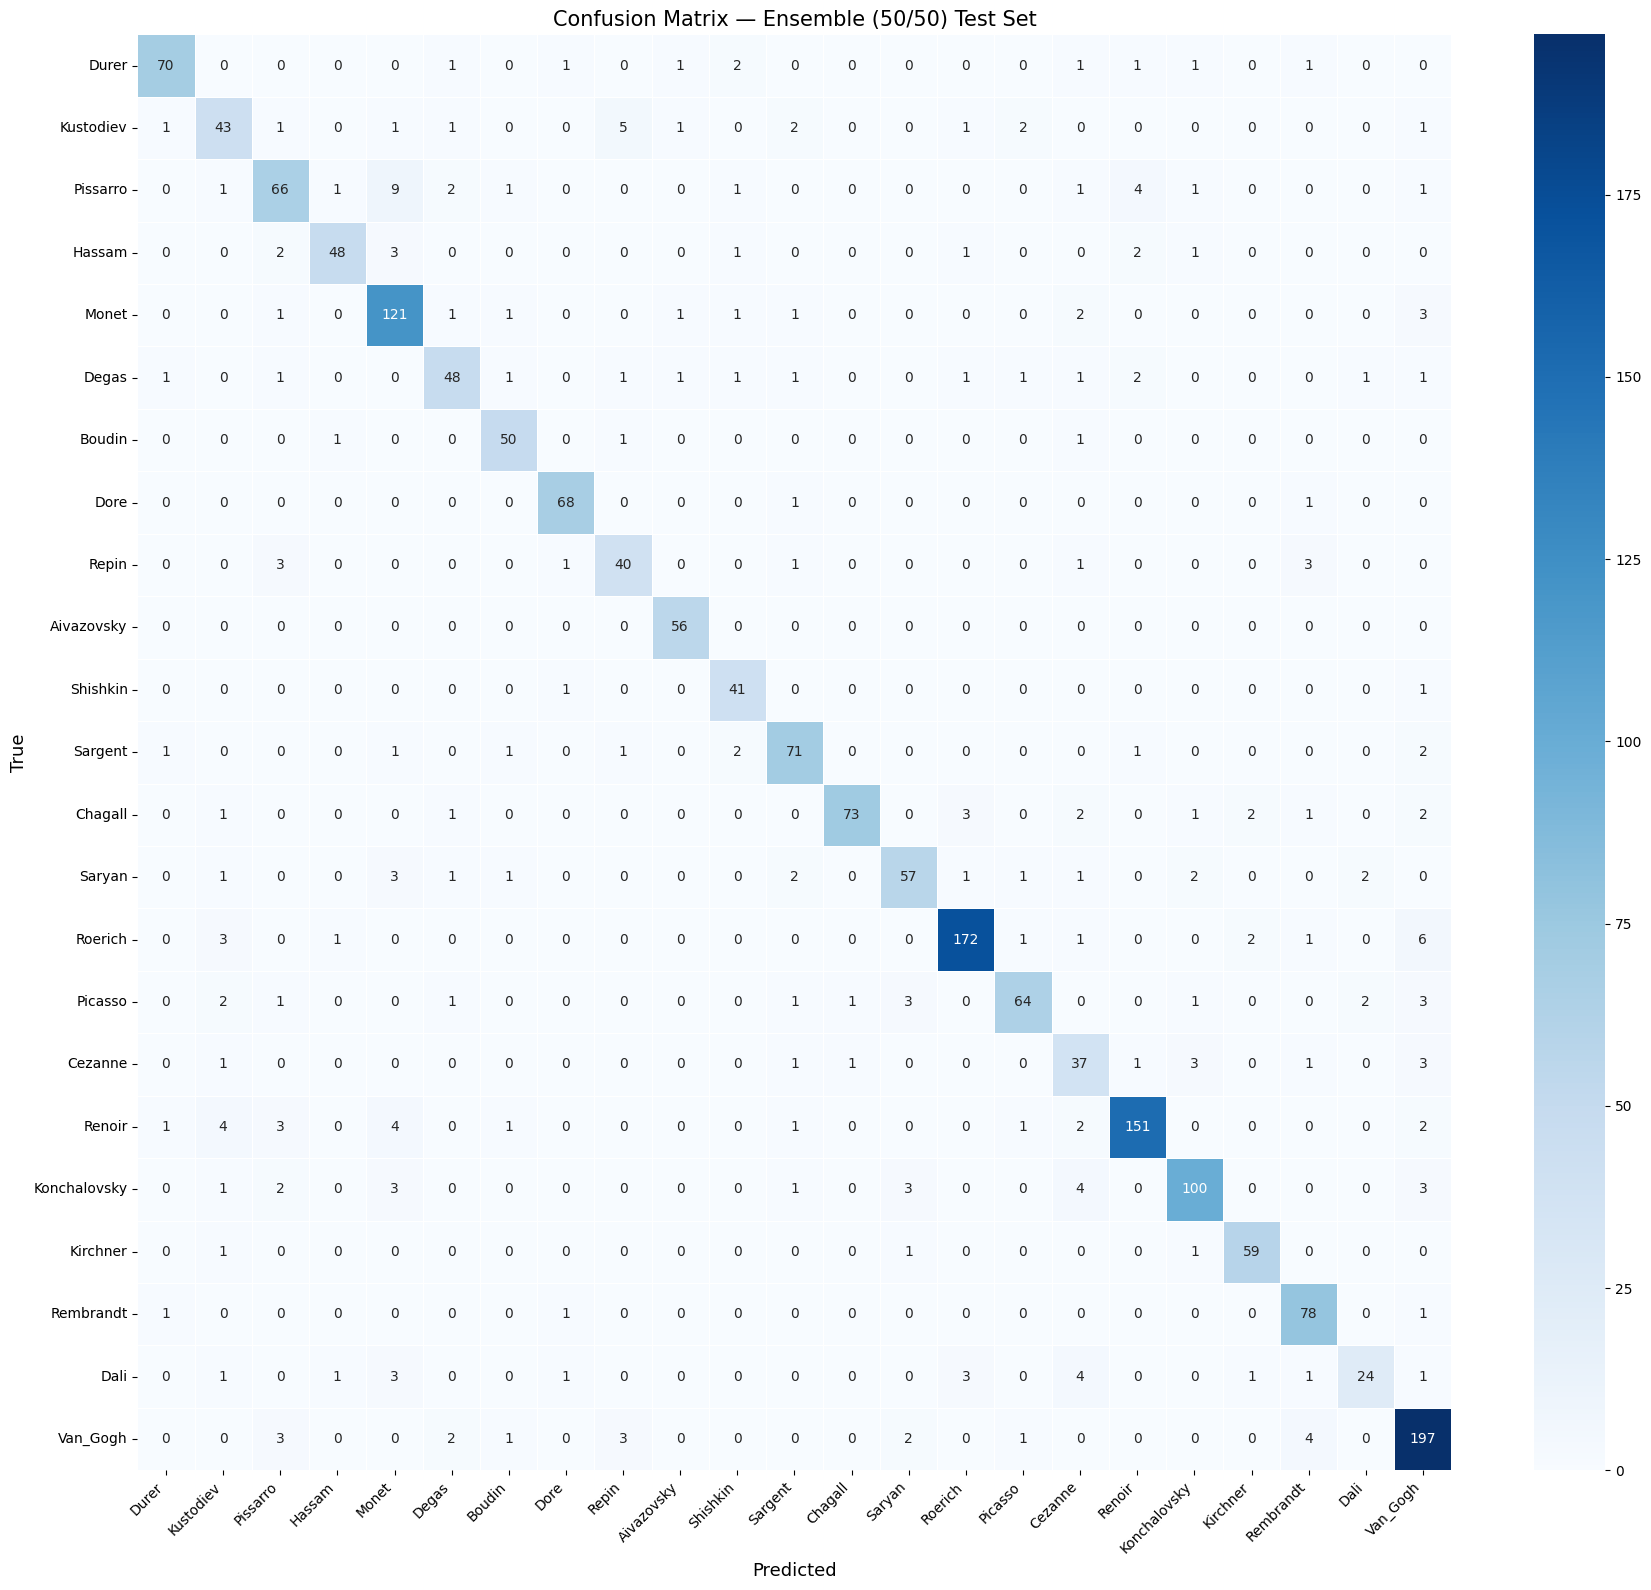

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(label_classes, pred_classes)

# Short names for readability
short_names = [
    "Durer", "Kustodiev", "Pissarro", "Hassam", "Monet",
    "Degas", "Boudin", "Dore", "Repin", "Aivazovsky",
    "Shishkin", "Sargent", "Chagall", "Saryan", "Roerich",
    "Picasso", "Cezanne", "Renoir", "Konchalovsky", "Kirchner",
    "Rembrandt", "Dali", "Van_Gogh"
]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_names,
    yticklabels=short_names,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title("Confusion Matrix — Ensemble (50/50) Test Set", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(all_labels_test, preds_ensemble_test,
                    multi_class="ovr", average="macro")
print(f"Macro ROC AUC: {auc:.4f}")

Macro ROC AUC: 0.9913


In [35]:
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(label_classes, pred_classes)
print(f"MCC: {mcc:.4f}")

MCC: 0.8667


In [36]:
confidences   = np.max(preds_ensemble_test, axis=1)
correct_mask  = (pred_classes == label_classes)

print(f"Mean confidence correct   : {confidences[correct_mask].mean():.4f}")
print(f"Mean confidence incorrect : {confidences[~correct_mask].mean():.4f}")

Mean confidence correct   : 0.7692
Mean confidence incorrect : 0.4015


In [ ]:
# ── 1. Feature extractors (correct penultimate layers) ────────────────────────

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    extractor_v2s = tf.keras.Model(
        inputs  = model_v2s.input,
        outputs = model_v2s.get_layer("dropout").output       # (None, 1280)
    )
    extractor_mob = tf.keras.Model(
        inputs  = model_mob.input,
        outputs = model_mob.get_layer("dropout_2").output     # (None, 960)
    )

# ── 2. Helpers ────────────────────────────────────────────────────────────────

def _undo_preprocess(img_array):
    """Values already in [0, 255] float — just cast."""
    return np.clip(img_array, 0, 255).astype(np.uint8)

def _extract_feat(arr):
    """Batch or single image → L2-normalised concatenated feature vector."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        f_v2s = extractor_v2s(arr, training=False).numpy()   # (B, 1280)
        f_mob = extractor_mob(arr, training=False).numpy()   # (B, 960)
    feats  = np.concatenate([f_v2s, f_mob], axis=1)         # (B, 2240)
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    return feats

# ── 3. Build train index (batch inference, not storing images in RAM) ───────────

def build_train_index(train_ds, class_names):
    all_labels, all_feats, all_refs = [], [], []

    for batch_idx, (images, labels) in enumerate(train_ds):
        feats      = _extract_feat(images)
        labels_np  = labels.numpy()
        label_ints = np.argmax(labels_np, axis=1) if labels_np.ndim == 2 else labels_np

        all_feats.append(feats.astype(np.float32))
        all_labels.extend([class_names[i] for i in label_ints])
        all_refs.extend([(batch_idx, i) for i in range(len(label_ints))])

        if batch_idx % 10 == 0:
            print(f"  Indexed {len(all_labels):,} training samples...")

    all_feats  = np.vstack(all_feats)
    all_labels = np.array(all_labels)
    all_refs   = np.array(all_refs)
    print(f"\nIndex ready: {len(all_labels):,} training samples.")
    return all_labels, all_feats, all_refs

# ── 4. Nearest-neighbour lookup restricted to predicted class ─────────────────

def find_nearest_train(feat, pred_cls, train_labels, train_feats, train_refs):
    mask      = train_labels == pred_cls
    sub_feats = train_feats[mask]
    sub_refs  = train_refs[mask]
    if len(sub_feats) == 0:
        return None, None, None
    cosine_dists        = 1 - sub_feats @ feat
    best                = np.argmin(cosine_dists)
    best_batch, best_sample = sub_refs[best]
    return int(best_batch), int(best_sample), float(cosine_dists[best])

# ── 5. Re-fetch one training image by its (batch_idx, sample_idx) ref ─────────

def fetch_train_image(train_ds, batch_idx, sample_idx):
    for i, (images, _) in enumerate(train_ds):
        if i == batch_idx:
            return _undo_preprocess(images.numpy()[sample_idx])
    return None

# ── 6. Plot ───────────────────────────────────────────────────────────────────

def _plot_pairs(misses, cols):
    if not misses:
        print("No misclassifications found.")
        return

    rows = (len(misses) + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 3.5, rows * 7))
    axes = axes.reshape(rows * 2, cols)

    for i, m in enumerate(misses):
        r, c = (i // cols) * 2, i % cols

        axes[r, c].imshow(m['test_img'])
        axes[r, c].set_title(
            f"TRUE: {m['true']}\n→ predicted: {m['pred']}",
            fontsize=8, color='firebrick', fontweight='bold'
        )
        axes[r, c].axis('off')

        axes[r+1, c].imshow(m['nn_img'])
        axes[r+1, c].set_title(
            f"NN train: {m['pred']}\ncosine dist: {m['nn_dist']:.3f}",
            fontsize=8, color='steelblue', fontweight='bold'
        )
        axes[r+1, c].axis('off')

    for i in range(len(misses), rows * cols):
        r, c = (i // cols) * 2, i % cols
        axes[r, c].axis('off')
        axes[r+1, c].axis('off')

    red  = mpatches.Patch(color='firebrick', label='Misclassified test image (true label)')
    blue = mpatches.Patch(color='steelblue', label='Most similar train image from predicted class')
    fig.legend(handles=[red, blue], loc='lower center', ncol=2, fontsize=9, frameon=False)
    plt.suptitle(
        "Misclassified test images — nearest train neighbour (ensemble features)",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig("misclassified_nn.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → misclassified_nn.png")

# ── 7. Main ───────────────────────────────────────────────────────────────────

def show_misclassified_nn(
    train_ds, class_names,
    preds_v2s_test, preds_mob_test, all_labels_test,
    test_ds,
    ensemble_weight=0.5, max_pairs=20, cols=4,
):
    print("Building training feature index...")
    train_labels, train_feats, train_refs = build_train_index(train_ds, class_names)

    preds_ensemble = (ensemble_weight       * preds_v2s_test +
                      (1 - ensemble_weight) * preds_mob_test)
    pred_classes  = np.argmax(preds_ensemble,  axis=1)
    label_classes = np.argmax(all_labels_test, axis=1)

    print("\nCollecting test images...")
    test_images_list = []
    for images, _ in test_ds:
        test_images_list.extend(images.numpy())

    print(f"Searching {len(pred_classes)} test samples for misclassifications...")
    misses = []
    for idx in range(len(pred_classes)):
        true_label = label_classes[idx]
        pred_label = pred_classes[idx]
        if true_label == pred_label:
            continue

        true_cls = class_names[true_label]
        pred_cls = class_names[pred_label]

        arr  = np.expand_dims(test_images_list[idx], 0)
        feat = _extract_feat(arr).squeeze()

        best_batch, best_sample, dist = find_nearest_train(
            feat, pred_cls, train_labels, train_feats, train_refs
        )
        if best_batch is None:
            continue

        nn_img = fetch_train_image(train_ds, best_batch, best_sample)

        misses.append({
            'test_img': _undo_preprocess(test_images_list[idx]),
            'true':     true_cls,
            'pred':     pred_cls,
            'nn_img':   nn_img,
            'nn_dist':  dist,
        })

        if len(misses) >= max_pairs:
            break

    print(f"Found {len(misses)} misclassified pairs. Plotting...")
    _plot_pairs(misses, cols)

# ── 8. Run ────────────────────────────────────────────────────────────────────

show_misclassified_nn(
    train_ds        = train_ds,
    class_names     = ds[0].class_names,
    preds_v2s_test  = preds_v2s_test,
    preds_mob_test  = preds_mob_test,
    all_labels_test = all_labels_test,
    test_ds         = test_ds,
    ensemble_weight = 0.5,
    max_pairs       = 20,
    cols            = 4,
)